<a href="https://colab.research.google.com/github/armaanrathod/EDA-lab-3rd-sem-final/blob/14th/Experiment1_Bank_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 1: Data Cleaning and Missing Value Handling
**Dataset:** `bank.csv` (Bank Marketing dataset)
**Goal:** produce a cleaned dataset (mirrors the Titanic-style experiment brief: clean data + handle missing values to prepare it for a prediction model — here, predicting `deposit`).

Steps followed: missing values → duplicates → irrelevant columns → malformed/categorical fixes → outliers → data types.

## 0. Import libraries and load data
Data is loaded with `pandas`/`numpy` — not manual file reading — so this notebook can pull the CSV straight from a GitHub raw URL once pushed to a repo.

In [ ]:
import pandas as pd
import numpy as np

# Local path for now — once this notebook + bank.csv are pushed to GitHub,
# swap this for: pd.read_csv("https://raw.githubusercontent.com/<user>/<repo>/main/bank.csv")
df = pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 1. Initial exploration

In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (11162, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,11162.0,NaN,NaN,NaN,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
job,11162,12,management,2566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,11162,3,married,6351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,11162,4,secondary,5476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,11162,2,no,10994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,11162.0,NaN,NaN,NaN,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
housing,11162,2,no,5881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,11162,2,no,9702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,11162,3,cellular,8042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,11162.0,NaN,NaN,NaN,15.658036,8.42074,1.0,8.0,15.0,22.0,31.0


## 2. Missing Values
This dataset has no literal `NaN`s, but several categorical columns use the string `"unknown"` as a placeholder for missing data — that has to be treated as missing, same as sir's market-analysis example treated blank cells.

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
unknown_pct = {c: round((df[c] == 'unknown').mean() * 100, 2) for c in cat_cols}
unknown_pct = {k: v for k, v in unknown_pct.items() if v > 0}
unknown_pct

{'job': np.float64(0.63),
 'education': np.float64(4.45),
 'contact': np.float64(21.02),
 'poutcome': np.float64(74.59)}

In [ ]:
# Treat 'unknown' as missing
df_clean = df.replace('unknown', np.nan)
missing_pct = (df_clean.isnull().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

poutcome     74.592367
contact      21.017739
education     4.452607
job           0.627128
dtype: float64

In [ ]:
# Rule of thumb (same as the housing example): drop columns missing more than 15% of their data
drop_threshold = 15
cols_to_drop = missing_pct[missing_pct > drop_threshold].index.tolist()
print("Dropping (too much missing):", cols_to_drop)
df_clean = df_clean.drop(columns=cols_to_drop)

Dropping (too much missing): ['poutcome', 'contact']


In [ ]:
# Remaining missing values are low (<5%) -> impute categoricals with the mode
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(remaining_missing)

for col in remaining_missing.index:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

print("\nMissing values left:", df_clean.isnull().sum().sum())

job           70
education    497
dtype: int64

Missing values left: 0


**Note on `pdays`:** a value of `-1` means the customer was never contacted before a campaign — this isn't a random gap, it's Missing Not At Random (MNAR): the value is absent *because* of what it represents. Rather than dropping/imputing it, we turn it into information with a flag column.

In [ ]:
df_clean['was_contacted_before'] = (df_clean['pdays'] != -1).astype(int)
df_clean[['pdays', 'was_contacted_before']].head()

,pdays,was_contacted_before
0,-1,0
1,-1,0
2,-1,0
3,-1,0
4,-1,0


## 3. Duplicates

In [ ]:
dupe_count = df_clean.duplicated().sum()
print("Duplicate rows found:", dupe_count)
df_clean = df_clean.drop_duplicates()
print("Shape after dropping duplicates:", df_clean.shape)

Duplicate rows found: 0
Shape after dropping duplicates: (11162, 16)


## 4. Irrelevant Columns
`duration` (last call duration in seconds) is known to leak the outcome — a call that lasted 0 seconds almost always means `deposit = no`. It's only known *after* the call ends, so it isn't a fair predictor and is standard to drop for this dataset.

In [ ]:
df_clean = df_clean.drop(columns=['duration'])
df_clean.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'day',
 'month',
 'campaign',
 'pdays',
 'previous',
 'deposit',
 'was_contacted_before']

## 5. Malformed / Categorical Fixes
Clean up text formatting and convert the target column to a proper binary label instead of yes/no strings.

In [ ]:
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip().str.lower()

df_clean['deposit'] = df_clean['deposit'].map({'yes': 1, 'no': 0})
df_clean[['deposit']].value_counts()

deposit
0          5873
1          5289
Name: count, dtype: int64

## 6. Outliers
Check `balance` (account balance) using the IQR method, a common outlier-detection technique.

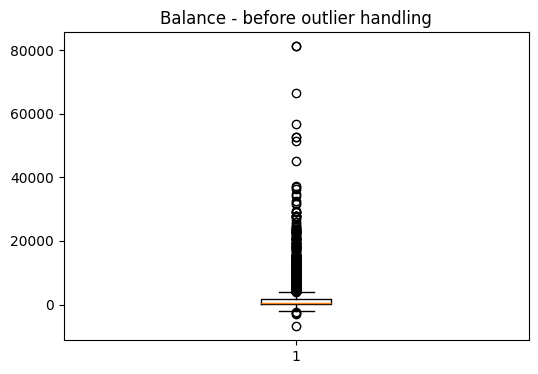

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df_clean['balance'])
plt.title('Balance - before outlier handling')
plt.show()

In [ ]:
Q1 = df_clean['balance'].quantile(0.25)
Q3 = df_clean['balance'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df_clean['balance'] < lower) | (df_clean['balance'] > upper)).sum()
print(f"Outliers in balance: {outlier_count} ({outlier_count/len(df_clean)*100:.1f}%)")

# Cap rather than delete -- keeps the rows, limits the extreme skew
df_clean['balance'] = df_clean['balance'].clip(lower=lower, upper=upper)

## 7. Data Types

In [ ]:
cat_cols_final = df_clean.select_dtypes(include='object').columns
df_clean[cat_cols_final] = df_clean[cat_cols_final].astype('category')
df_clean.dtypes

## 8. Final Cleaned Dataset

In [ ]:
print("Final shape:", df_clean.shape)
df_clean.head()

In [1]:
df_clean.to_csv("bank_cleaned.csv", index=False)
print("Saved bank_cleaned.csv")

NameError: name 'df_clean' is not defined